*This jupyter notebook will give an insight of the basic model manipulations.*


### Setting up environment 

add the metabolite summary
add FVA alysis
https://cobrapy.readthedocs.io/en/latest/autoapi/cobra/flux_analysis/variability/index.html add these also

In [ ]:
%pip install cobra

In [1]:
import cobra
import pandas as pd
from cobra.io import load_model
from cobra.io import load_json_model, save_json_model, load_matlab_model, save_matlab_model, read_sbml_model, write_sbml_model
from cobra import Model, Reaction, Metabolite, Gene
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

### Read model

In [2]:
model = read_sbml_model('241209_NGAM_coef_update_GAM.sbml')

### Model fluxes summary

In [3]:
model.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
ca2_e,EX_ca2_e,0.0002288,0,0.00%
cl_e,EX_cl_e,0.0002288,0,0.00%
co2_e,EX_co2_e,2.207,1,100.00%
cobalt2_e,EX_cobalt2_e,1.109E-06,0,0.00%
cu2_e,EX_cu2_e,0.0003116,0,0.00%
fe2_e,EX_fe2_e,0.0006692,0,0.00%
h2_e,EX_h2_e,19.4,0,0.00%
k_e,EX_k_e,0.008579,0,0.00%
mg2_e,EX_mg2_e,0.0003813,0,0.00%
mn2_e,EX_mn2_e,3.04E-05,0,0.00%


## Reaction manipulation

#### Set reaction bounds

In [ ]:
# set the reaction name of your choice instead of 'HYD1pp'
model.reactions.get_by_id('HYD1pp').bounds = -0.0, 0.0

#### Set exchange reactions bounds

In [ ]:
# set reactions bounds for a specific reaction 
reaction = model.reactions.get_by_id('EX_h2_e')
reaction.bounds = -19.48, 0.0

reaction = model.reactions.get_by_id('EX_o2_e')
reaction.bounds = -6.92, 0.0

reaction = model.reactions.get_by_id('EX_ac_e')
reaction.bounds = -2.50, 0.0

#### Check reaction information

In [7]:
reaction_id_to_check = 'HYD1pp'
reaction = model.reactions.get_by_id(reaction_id_to_check)
print(f"Reaction ID: {reaction.id}")
print(f"Name: {reaction.name}")
print(f"Equation: {reaction.reaction}")
print(f"Lower Bound: {reaction.lower_bound}")
print(f"Upper Bound: {reaction.upper_bound}")
sum = 0
#reaction.name = '(S)-2-Acetolactate pyruvate-lyase (carboxylating)'
print("\nMetabolites and Stoichiometry:")
for metabolite, coefficient in reaction.metabolites.items():
    print(f"{metabolite.id:<15}: {coefficient:>25}  Name: {metabolite.name:<60}  Charge: {metabolite.charge:>3}  Formula: {metabolite.formula}")
    sum += coefficient * metabolite.charge
print(f'\nSum charge: {sum}')
print("\nAssociated Genes:")
for gene in reaction.genes:
    print(gene.id)

Reaction ID: HYD1pp
Name: Hydrogenase (ubiquinone-8: 2 protons) (periplasm)
Equation: h2_c + 2.0 h_c + q8_c --> 2.0 h_p + q8h2_c
Lower Bound: 0.0
Upper Bound: 1000.0

Metabolites and Stoichiometry:
h2_c           :                      -1.0  Name: Hydrogen                                                      Charge:   0  Formula: H2
h_c            :                      -2.0  Name: H+                                                            Charge:   1  Formula: H
q8_c           :                      -1.0  Name: Ubiquinone-8                                                  Charge:   0  Formula: C49H74O4
h_p            :                       2.0  Name: H+                                                            Charge:   1  Formula: H
q8h2_c         :                       1.0  Name: Ubiquinol-8                                                   Charge:   0  Formula: C49H76O4

Sum charge: 0.0

Associated Genes:
AAFOLC_02510
AAFOLC_02515
AAFOLC_02505


#### Create a dataframe with significant reaction fluxes

In [8]:
solution = model.optimize()
significant_reactions = [
    [
        model.reactions[RctIdx].name, 
        solution.to_frame().iloc[RctIdx].name, 
        model.reactions[RctIdx].reaction, 
        round(solution.fluxes[RctIdx], 2)
    ]
    for RctIdx in np.where(np.abs(solution.fluxes) > 3)[0]
]

# Create a DataFrame for better visualization
df = pd.DataFrame(significant_reactions, columns=["Reaction Name", "Reaction ID", "Reaction Equation", "Flux"])

# Print the DataFrame
df

C:\Users\adam-1y9pxi6q95ggpmx\AppData\Local\Temp\ipykernel_7072\4250613037.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  round(solution.fluxes[RctIdx], 2)


,Reaction Name,Reaction ID,Reaction Equation,Flux
0,EX_h2_e,EX_h2_e,h2_e <--,-18.78
1,EX_h2o_e,EX_h2o_e,h2o_e <=>,17.54
2,EX_o2_e,EX_o2_e,o2_e <--,-6.92
3,ATP synthase (four protons for one ATP) (perip...,ATPS4rpp,adp_c + 4.0 h_p + pi_c <=> atp_c + h2o_c + 3.0...,20.78
4,Cytochrome oxidase bd (ubiquinol-8: 2 protons)...,CYTBDpp,2.0 h_c + 0.5 o2_c + q8h2_c --> h2o_c + 2.0 h_...,13.85
5,Glyceraldehyde-3-phosphate dehydrogenase,GAPD,g3p_c + nad_c + pi_c <=> 13dpg_c + h_c + nadh_c,-3.72
6,Bidirectional [NiFe] Hydrogenase,H2ASE_syn,h_c + nadph_c <=> h2_c + nadp_c,-18.78
7,H2O transport via diffusion,H2Ot,h2o_e <=> h2o_c,-17.54
8,Hydrogen transport via diffusion (extracellula...,H2tex,h2_e <=> h2_p,18.78
9,Hydrogen transport diffusion (periplasm),H2tpp,h2_p <=> h2_c,18.78


## Plotting

### Open experimental growth data

In [ ]:
#file_path ='C:\\Users\\adam-1y9pxi6q95ggpmx\\Documents\\PhD\\10-19 Research\\11 Data\\11.03 Fluxes values\\plot_data - Copy.xlsx'
file_path ='240823_growth_data.xlsx'
excel_data = pd.read_excel(file_path)
#excel_data = excel_data.drop([0,16])
excel_data

### Simulate the growth with the different experimental constraints

In [ ]:

#addition of a growth rate column
excel_data['growth_rate'] = None
for index, row in excel_data.iterrows():
    
    # Set bounds for H2 flux
    h2_reaction = model.reactions.get_by_id('EX_h2_e')
    h2_reaction.bounds = (-row['H2 Flux theoretic'], 0.0)

    # Set bounds for O2 flux
    o2_reaction = model.reactions.get_by_id('EX_o2_e')
    o2_reaction.bounds = (-100, 0.0)

    # Set bounds for CO2 flux
    co2_reaction = model.reactions.get_by_id('EX_co2_e')
    co2_reaction.bounds = (-row['CO2 flux theoretic'], 0.0)

    # Optimize the model
    solution = model.slim_optimize()
    #you can remove the # to print the result
    #print(solution)
    #print(model.reactions.get_by_id('EX_h2_e').flux)
    #print(model.reactions.get_by_id('EX_o2_e').flux)
    #print(model.reactions.get_by_id('EX_co2_e').flux)


    # Update the DataFrame with the solution
    excel_data.at[index, 'growth_rate'] = solution

    # Assuming `solution` is an object that has a `fluxes` attribute
    excel_data.at[index, 'H2 Flux model'] = model.reactions.get_by_id('EX_h2_e').flux
    excel_data.at[index, 'O2 Flux model'] = model.reactions.get_by_id('EX_o2_e').flux
    excel_data.at[index, 'CO2 Flux model'] = model.reactions.get_by_id('EX_co2_e').flux

### Plot simulated data against experimental data

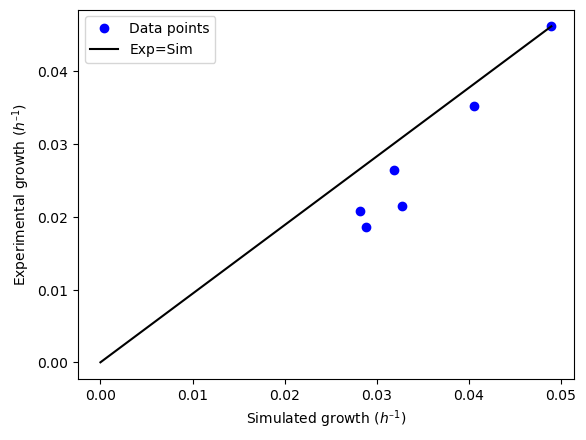

In [ ]:
experimental_growth = excel_data['dilRate']
simulated_growth = excel_data['growth_rate']

# Plotting the data
plt.plot(simulated_growth, experimental_growth, 'o', color='blue', label='Data points')

plt.plot([0, max(simulated_growth)], [0, max(experimental_growth)], 'k-', label='Exp=Sim')

# Labels and legend
plt.xlabel('Simulated growth ($h^{–1}$)')
plt.ylabel('Experimental growth ($h^{–1}$)')
plt.legend()

# Save the plot (optional)
#plt.savefig('Plotting simulation and measured growth.png')

# Display the plot
plt.show()

### Create a dataframe of different h2 uptake rate depending of co2 uptake rate

In [ ]:
# Define the empty DataFrame for growth data
growth_data = {'growth_rate': [], 'H2 Flux model': [], 'O2 Flux model': [], 'CO2 Flux model': []}
sim_growth_df = pd.DataFrame(growth_data)
rows_list = []

# Set bounds for O2 flux
o2_reaction = model.reactions.get_by_id('EX_o2_e')
o2_reaction.bounds = (-100, 0.0)

# Set bounds for CO2 flux
co2_reaction = model.reactions.get_by_id('EX_co2_e')
co2_reaction.bounds = (-100, 0.0)

# Use np.arange to create a range with a step size of 0.5
for h2_flux in np.arange(5, 21, 0.5):  # Start at 14, end at 21, with step size of 0.5
    
    # Set bounds for H2 flux
    h2_reaction = model.reactions.get_by_id('EX_h2_e')
    h2_reaction.bounds = (-h2_flux, 0.0)

    # Optimize the model
    solution = model.slim_optimize()

    row = {
        'growth_rate': solution,
        'H2 Flux model': model.reactions.get_by_id('EX_h2_e').flux,
        'O2 Flux model': model.reactions.get_by_id('EX_o2_e').flux,
        'CO2 Flux model': model.reactions.get_by_id('EX_co2_e').flux
    }
    rows_list.append(row)

# Convert the list of rows into a DataFrame
sim_growth_df = pd.DataFrame(rows_list)

# Plotting growth rate vs. H2 uptake rate
plt.figure(figsize=(8, 6))
plt.plot(-sim_growth_df['H2 Flux model'], sim_growth_df['growth_rate'], marker='o', linestyle='-', color='blue')

# Adding labels and title
plt.xlabel('H2 Uptake Rate (mmol/gDW/hr)')
plt.ylabel('Growth Rate (h$^{-1}$)')
plt.title('Growth Rate vs. H2 Uptake Rate')

# Show grid
plt.grid(True)

# Save the figure (optional)
#plt.savefig('growth_rate_vs_h2_uptake_rate.png')

# Show the plot
plt.show()

c:\Users\adam-1y9pxi6q95ggpmx\AppData\Local\anaconda3\Lib\site-packages\cobra\util\solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


### GAM & NGAM manipulation

#### Set the ATPM bounds (NGAM)

In [ ]:
reaction = model.reactions.get_by_id('ATPM')
reaction.bounds = 11.55, 1000.0

#### Set the GAM

In [ ]:
GAM_metabolites_1 = {'atp_c': -75.5, 'h2o_c': -75.5}
GAM_metabolites_2 = {'adp_c': 75.5, 'pi_c': 75.5, 'h_c': 75.5}

# Set bounds for O2 flux
o2_reaction = model.reactions.get_by_id('EX_o2_e')
o2_reaction.bounds = (-100, 0.0)

# Get the biomass reaction
reaction = model.reactions.get_by_id('Growth')

# Update the coefficients for GAM_metabolites_1
for element, new_coefficient in GAM_metabolites_1.items():
    metabolite = model.metabolites.get_by_id(element)
    if metabolite in reaction.metabolites:
        print(f'Old coefficient for {element}: {reaction.metabolites[metabolite]}')
        reaction.add_metabolites({metabolite: new_coefficient - reaction.metabolites[metabolite]})
        print(f'Updated {element} coefficient to {new_coefficient}')

# Update the coefficients for GAM_metabolites_2
for element, new_coefficient in GAM_metabolites_2.items():
    metabolite = model.metabolites.get_by_id(element)
    if metabolite in reaction.metabolites:
        print(f'Old coefficient for {element}: {reaction.metabolites[metabolite]}')
        reaction.add_metabolites({metabolite: new_coefficient - reaction.metabolites[metabolite]})
        print(f'Updated {element} coefficient to {new_coefficient}')

# Optimize the model
solution = model.slim_optimize()
print(f'Optimal solution: {solution}')

### Calculate growth for different H2 values

In [8]:
# Define the empty DataFrame for growth data
growth_data = {'growth_rate': [], 'H2 Flux model': [], 'O2 Flux model': [], 'CO2 Flux model': []}
sim_growth_df = pd.DataFrame(growth_data)
rows_list = []

# Set bounds for O2 flux
o2_reaction = model.reactions.get_by_id('EX_o2_e')
o2_reaction.bounds = (-100, 0.0)

# Set bounds for CO2 flux
co2_reaction = model.reactions.get_by_id('EX_co2_e')
co2_reaction.bounds = (-100, 0.0)

# Use np.arange to create a range with a step size of 0.5
for h2_flux in np.arange(11, 21, 0.5):  # Start at 14, end at 21, with step size of 0.5
    
    # Set bounds for H2 flux
    h2_reaction = model.reactions.get_by_id('EX_h2_e')
    h2_reaction.bounds = (-h2_flux, 0.0)

    # Optimize the model
    solution = model.slim_optimize()

    row = {
        'growth_rate': solution,
        'H2 Flux model': model.reactions.get_by_id('EX_h2_e').flux,
        'O2 Flux model': model.reactions.get_by_id('EX_o2_e').flux,
        'CO2 Flux model': model.reactions.get_by_id('EX_co2_e').flux
    }
    rows_list.append(row)

# Convert the list of rows into a DataFrame
sim_growth_df = pd.DataFrame(rows_list)

save in excel(optional)

In [ ]:
sim_growth_df.to_excel('241209_sim_data_growth_85.7.xlsx')

load experimental data

In [5]:
df = pd.read_excel("240702_NGAM_data.xlsx")
#we will clean the data
df_ngam = df[['dilRate','H2 Flux theoretic']].copy()
#df_ngam = df_ngam.dropna(subset=['H2 Flux theoretic'])
df_grouped = df_ngam.groupby(df_ngam.index // 3).mean()
df_grouped[['dilRate_std','h2_std']] = df_ngam.groupby(df_ngam.index // 3).std()
df_grouped

,dilRate,H2 Flux theoretic,dilRate_std,h2_std
0,0.046160,19.489454,0.000154,0.384852
1,0.035260,17.380479,0.001252,0.097607
2,0.026357,15.628204,0.000116,0.220718
3,0.020724,15.387005,0.000506,0.343749
4,0.021499,18.837676,0.000000,0.923094
5,0.018587,17.710821,0.000190,0.166635


plot

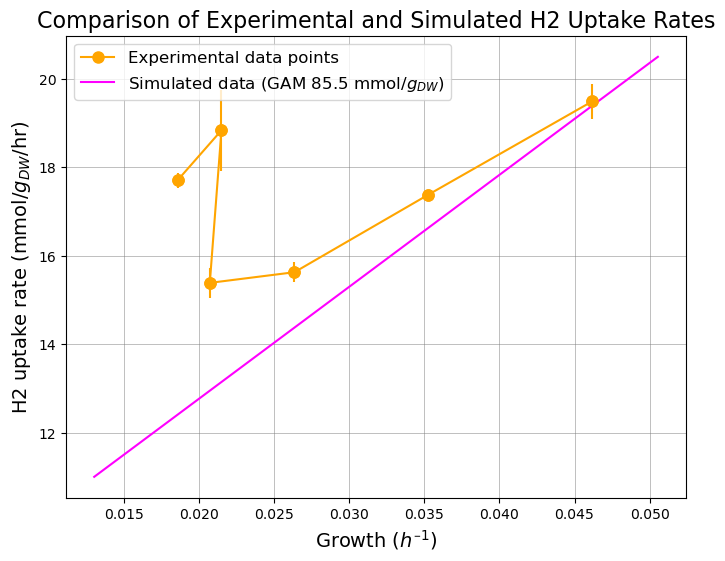

In [9]:
# Ensure the growth_rate and h2_flux_experimental are properly defined based on the cleaned data
growth_rate_cleaned = df_grouped['dilRate']
h2_flux_experimental_cleaned = df_grouped['H2 Flux theoretic']

# Load the simulated data
sim_growth_rate = sim_growth_df['growth_rate']
sim_h2_flux = sim_growth_df['H2 Flux model']

# Plot the experimental and simulated data
plt.figure(figsize=(8, 6))

# Experimental data (already cleaned and grouped)
plt.plot(growth_rate_cleaned, h2_flux_experimental_cleaned, label='Experimental data points', marker='o', color='orange', markersize=8, )
plt.errorbar(growth_rate_cleaned, h2_flux_experimental_cleaned, yerr=df_grouped['h2_std'], fmt='o', color='orange', markersize=8)

# Simulated data (from the new uploaded file)
plt.plot(sim_growth_rate, -sim_h2_flux, label='Simulated data (GAM 85.5 mmol/${g}_{{DW}}$)', color='magenta' , markersize=8, )


# Labels and title
plt.xlabel(r'Growth ($h^{–1}$)', fontsize=14)
plt.ylabel('H2 uptake rate (mmol/${g}_{{DW}}$/hr)', fontsize=14)
plt.title('Comparison of Experimental and Simulated H2 Uptake Rates', fontsize=16)

# Customize grid and make it brighter
plt.grid(True, which='both', axis='both', color='gray', linestyle='-', linewidth=0.5, alpha=0.7)

# Adjust legend font size
plt.legend(fontsize=12)

# Display the plot
plt.show()